# Bayesian Thinking for Threat Intelligence

Threat intelligence is inherently Bayesian: you start with a belief about threat likelihood,
observe indicators, and update. The problem is that most security teams do this intuitively
--- which means they anchor on vivid threats, ignore base rates, and overweight the latest
advisory. This notebook makes the update process explicit and quantitative.

**Prerequisites:** Part 0 covered Bayesian foundations including Raiffa's tree-flipping for
IDS alerts and beta-binomial updating for patch compliance. Here we go deeper: sequential
multi-source updating, likelihood ratios, odds-form reasoning, and forecast calibration.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from decision_security.synth import make_rng, sample
from decision_security.bayes import (
    beta_update, brier_score, calibration_curve,
    normal_update_known_variance, logit, inv_logit
)

rng = make_rng(42)

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PRIMARY = "#1A1A1A"
ACCENT = "#E74C3C"
DARK_BG = "#34495E"
LIGHT_GRAY = "#95A5A6"
MED_GRAY = "#7F8C8D"
VERY_LIGHT = "#BDC3C7"

## 1. Prior Elicitation --- What Do You Believe Before the Evidence?

Every Bayesian analysis starts with a prior. In security, the prior is your belief about
threat probability *before* you see any specific intelligence. The prior should reflect
your general knowledge --- industry base rates, historical data, organizational context
--- not the specific alert you're about to analyze.

Three common starting points:

| Prior | When to use |
|-------|-------------|
| **Uninformative** Beta(1,1) | No historical data at all; every probability equally plausible |
| **Mildly informed** Beta(2,20) | Sector averages suggest ~10% chance; modest confidence |
| **Strong** Beta(1,99) | Extensive data shows ~1% base rate; high confidence |

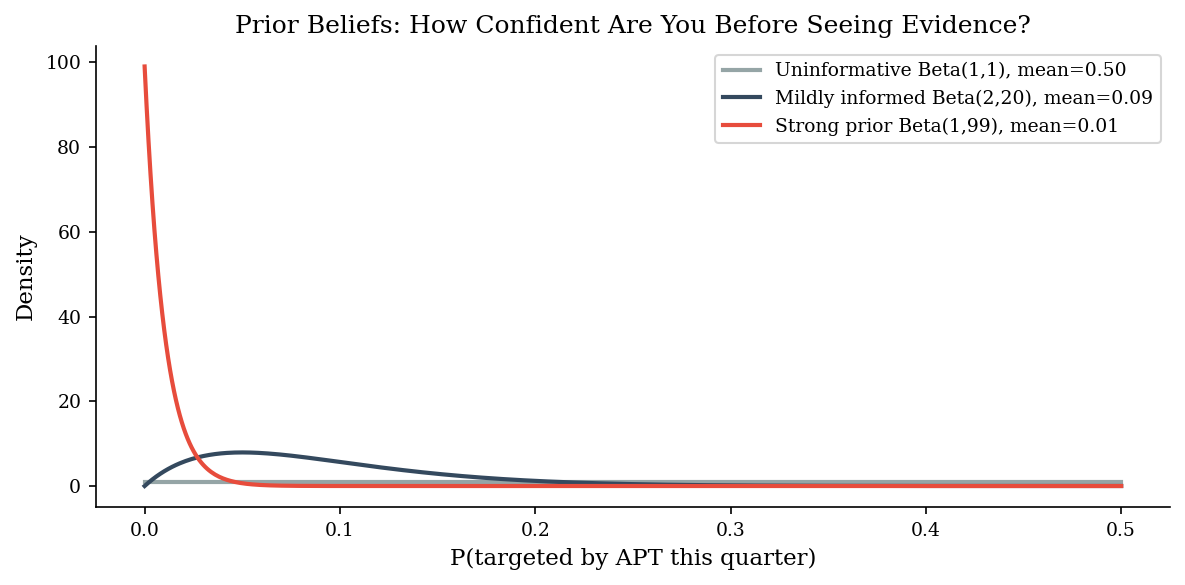

In [2]:
x = np.linspace(0, 0.5, 500)
priors = [
    ("Uninformative Beta(1,1)", 1, 1),
    ("Mildly informed Beta(2,20)", 2, 20),
    ("Strong prior Beta(1,99)", 1, 99),
]

fig, ax = plt.subplots(figsize=(8, 4))
colors_prior = [LIGHT_GRAY, DARK_BG, ACCENT]
for (label, a, b), color in zip(priors, colors_prior):
    pdf = stats.beta.pdf(x, a, b)
    mean = a / (a + b)
    ax.plot(x, pdf, linewidth=2, color=color,
            label=f"{label}, mean={mean:.2f}")

ax.set_xlabel("P(targeted by APT this quarter)")
ax.set_ylabel("Density")
ax.set_title("Prior Beliefs: How Confident Are You Before Seeing Evidence?")
ax.legend()
plt.tight_layout()
plt.show()

The uninformative prior says "I have no idea" --- every probability from 0 to 1 is
equally plausible. This is rarely honest in security; you almost always know *something*.
The mildly informed prior centers around 10% but is wide enough to move easily with new
evidence. The strong prior is concentrated near 1% and will require substantial evidence
to shift.

**Key insight:** the strength of a prior is determined by its *effective sample size*
(a + b for a Beta distribution). Beta(1,1) has sample size 2 --- trivially overridden.
Beta(1,99) has sample size 100 --- you need dozens of observations to move it.

## 2. Sequential Updating with Multiple Sources

Real threat intel comes in waves. A vendor advisory arrives (source 1), then a
sector-specific ISAC alert (source 2), then your own SIEM correlation (source 3).
Each source has different reliability and sample size. Bayesian updating lets you
combine them sequentially --- each posterior becomes the next prior.

**Scenario:** We are tracking whether a specific vulnerability (a recent RCE in an
edge device) is being actively exploited in the wild.

- **Prior:** Beta(2, 18) --- we think roughly 10% chance of active exploitation,
  based on historical rates for similar vulnerabilities.
- **Source 1 (vendor advisory):** reports 3 confirmed exploitations out of 20
  monitored organizations.
- **Source 2 (ISAC report):** reports 5 exploitations out of 15 peer organizations.
- **Source 3 (internal SIEM):** 0 exploit attempts detected across 100 monitored
  endpoints in our own network.

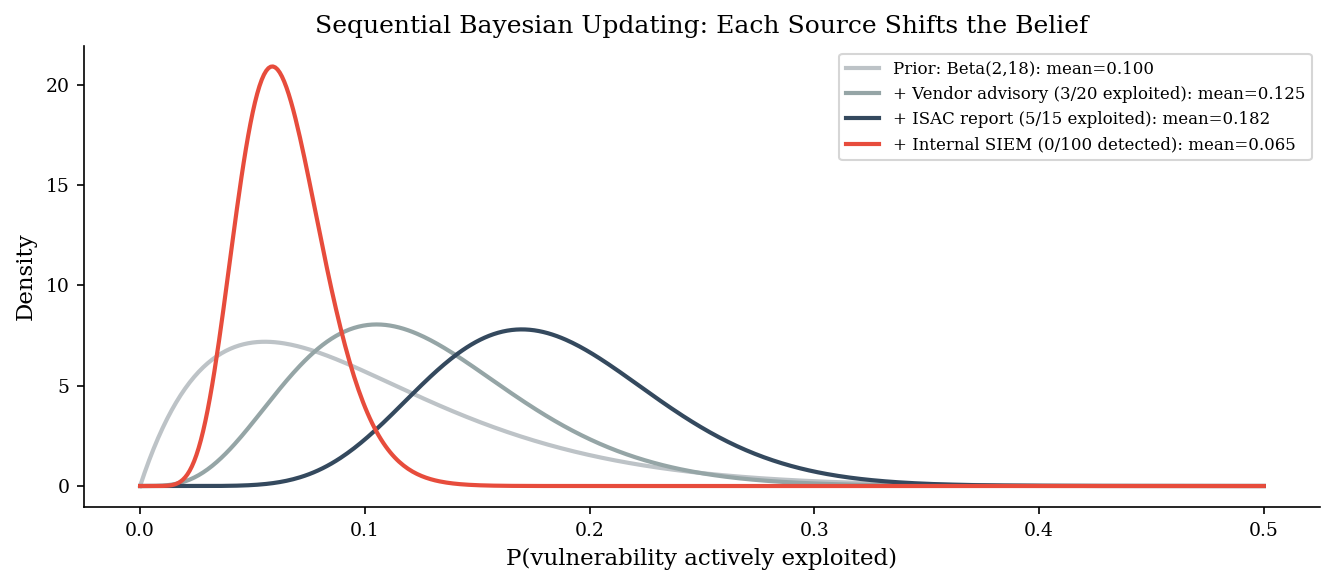

The external sources pushed the probability UP (from 10% to ~15%),
but 100 internal non-detections pulled it back DOWN (~7%).
The final estimate reflects ALL evidence, weighted by sample size.


In [3]:
a, b = 2, 18
updates = [
    ("Prior: Beta(2,18)", a, b),
]

sources = [
    ("+ Vendor advisory (3/20 exploited)", 3, 17),
    ("+ ISAC report (5/15 exploited)", 5, 10),
    ("+ Internal SIEM (0/100 detected)", 0, 100),
]

for name, s, f in sources:
    a, b = beta_update(a, b, s, f)
    updates.append((name, a, b))

# --- Plot all four distributions ---
fig, ax = plt.subplots(figsize=(9, 4))
x = np.linspace(0, 0.5, 500)
colors_seq = [VERY_LIGHT, LIGHT_GRAY, DARK_BG, ACCENT]

for (label, a_val, b_val), color in zip(updates, colors_seq):
    pdf = stats.beta.pdf(x, a_val, b_val)
    mean = a_val / (a_val + b_val)
    ax.plot(x, pdf, linewidth=2, color=color,
            label=f"{label}: mean={mean:.3f}")

ax.set_xlabel("P(vulnerability actively exploited)")
ax.set_ylabel("Density")
ax.set_title("Sequential Bayesian Updating: Each Source Shifts the Belief")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print("The external sources pushed the probability UP (from 10% to ~15%),")
print("but 100 internal non-detections pulled it back DOWN (~7%).")
print("The final estimate reflects ALL evidence, weighted by sample size.")

Notice two things:

1. **The posterior gets narrower with each update.** More data means more certainty,
   regardless of direction.
2. **The internal SIEM (0/100) dominates.** It contributes 100 observations --- more
   than the vendor and ISAC combined. Large, local datasets outweigh small, external
   ones. This is correct behavior: your own network's evidence should weigh heavily.

## 3. Likelihood Ratios --- How Strong Is the Evidence?

Not all evidence is equally informative. A **likelihood ratio** (LR) quantifies how
much a piece of evidence should shift your belief:

$$\text{LR}^+ = \frac{\text{TPR}}{\text{FPR}} = \frac{P(\text{indicator} \mid \text{compromised})}{P(\text{indicator} \mid \text{not compromised})}$$

- **LR > 10:** strong evidence for the hypothesis
- **LR 2--10:** moderate evidence
- **LR < 2:** weak evidence --- barely worth updating on

The critical insight: an indicator's *hit rate* (TPR) tells you very little on its own.
What matters is the **ratio** of true positives to false positives.

In [4]:
indicators = pd.DataFrame([
    {"indicator": "Known C2 domain in DNS logs", "tpr": 0.85, "fpr": 0.001},
    {"indicator": "Anomalous login time",        "tpr": 0.60, "fpr": 0.15},
    {"indicator": "Failed auth spike",            "tpr": 0.70, "fpr": 0.10},
    {"indicator": "Vendor threat advisory",       "tpr": 0.40, "fpr": 0.05},
    {"indicator": "Antivirus signature match",   "tpr": 0.95, "fpr": 0.08},
])
indicators["LR+"] = indicators["tpr"] / indicators["fpr"]
indicators["LR-"] = (1 - indicators["tpr"]) / (1 - indicators["fpr"])

# Sort by LR+ descending
indicators = indicators.sort_values("LR+", ascending=False)

print("Likelihood Ratios for Security Indicators")
print("LR+ > 10: strong evidence FOR  |  LR+ < 2: weak evidence")
print()
print(indicators[["indicator", "tpr", "fpr", "LR+"]].to_string(index=False))

Likelihood Ratios for Security Indicators
LR+ > 10: strong evidence FOR  |  LR+ < 2: weak evidence

                  indicator  tpr   fpr     LR+
Known C2 domain in DNS logs 0.85 0.001 850.000
  Antivirus signature match 0.95 0.080  11.875
     Vendor threat advisory 0.40 0.050   8.000
          Failed auth spike 0.70 0.100   7.000
       Anomalous login time 0.60 0.150   4.000


The C2 domain hit has an LR of 850 --- seeing it in your DNS logs is devastating
evidence of compromise. But look at the antivirus signature match: despite a 95% TPR
(sounds great!), its 8% FPR gives it an LR of only ~12. An anomalous login time is
even weaker at LR ~4.

**Takeaway:** stop evaluating indicators by their detection rate alone. The false
positive rate is equally important, and the ratio between them is what actually
determines evidential strength.

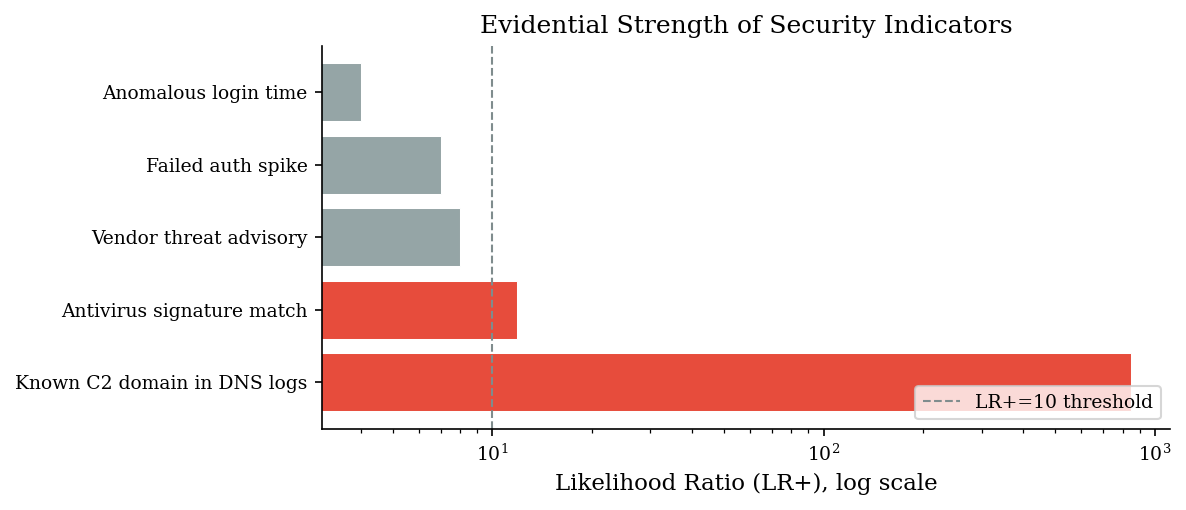

In [5]:
# Visualize: LR+ on a log scale to show the orders-of-magnitude differences
fig, ax = plt.subplots(figsize=(8, 3.5))

y_pos = range(len(indicators))
bars = ax.barh(y_pos, indicators["LR+"].values,
               color=[ACCENT if lr > 10 else LIGHT_GRAY
                      for lr in indicators["LR+"].values],
               edgecolor="white", linewidth=0.5)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(indicators["indicator"].values)
ax.set_xscale("log")
ax.set_xlabel("Likelihood Ratio (LR+), log scale")
ax.set_title("Evidential Strength of Security Indicators")
ax.axvline(10, color=MED_GRAY, linestyle="--", linewidth=1, label="LR+=10 threshold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. From Prior Odds to Posterior Odds

The odds form of Bayes' theorem is often more intuitive for working practitioners:

$$\text{posterior odds} = \text{prior odds} \times \text{likelihood ratio}$$

If your prior odds of compromise are 1:99 (1% probability) and you observe a C2
domain hit (LR = 850), your posterior odds are 850:99, which is approximately 8.6:1
(~90% probability). **One strong indicator can shift a rare event to near-certainty.**

Multiple independent indicators multiply: posterior odds = prior odds x LR1 x LR2 x ...

In [6]:
prior_p = 0.01
prior_odds = prior_p / (1 - prior_p)

# Apply C2 domain indicator (LR = TPR/FPR = 0.85/0.001 = 850)
lr_c2 = 0.85 / 0.001
posterior_odds_1 = prior_odds * lr_c2
posterior_p_1 = posterior_odds_1 / (1 + posterior_odds_1)

# Then apply anomalous login indicator (LR = 0.60/0.15 = 4)
lr_login = 0.60 / 0.15
posterior_odds_2 = posterior_odds_1 * lr_login
posterior_p_2 = posterior_odds_2 / (1 + posterior_odds_2)

print(f"Prior:                 P(compromised) = {prior_p:.3f}  (odds {prior_odds:.4f})")
print(f"After C2 domain:       P(compromised) = {posterior_p_1:.3f}  (LR = {lr_c2:.0f})")
print(f"After anomalous login: P(compromised) = {posterior_p_2:.3f}  (LR = {lr_login:.1f})")
print()
print(f"Two indicators, combined properly, take us from {prior_p:.0%} to",
      f"{posterior_p_2:.0%} probability of compromise.")

Prior:                 P(compromised) = 0.010  (odds 0.0101)
After C2 domain:       P(compromised) = 0.896  (LR = 850)
After anomalous login: P(compromised) = 0.972  (LR = 4.0)

Two indicators, combined properly, take us from 1% to 97% probability of compromise.


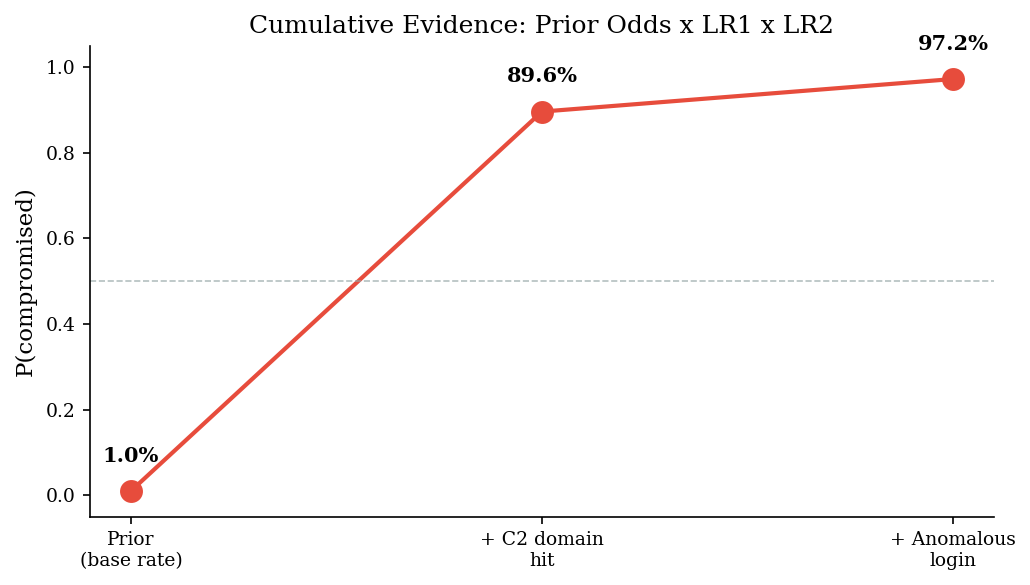

In [7]:
# Visualize the probability trajectory
stages = ["Prior\n(base rate)", "+ C2 domain\nhit", "+ Anomalous\nlogin"]
probs = [prior_p, posterior_p_1, posterior_p_2]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(stages)), probs, "o-", color=ACCENT, markersize=10, linewidth=2)
for i, (stage, prob) in enumerate(zip(stages, probs)):
    ax.annotate(f"{prob:.1%}", (i, prob), textcoords="offset points",
                xytext=(0, 14), ha="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(stages)))
ax.set_xticklabels(stages)
ax.set_ylabel("P(compromised)")
ax.set_title("Cumulative Evidence: Prior Odds x LR1 x LR2")
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.5, color=LIGHT_GRAY, linestyle="--", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Calibration --- Are Your Probability Estimates Any Good?

Bayesian updating only works if your inputs are calibrated. If you say "70% chance
of exploitation" for 100 vulnerabilities, roughly 70 should actually be exploited.
Most security analysts are **overconfident** --- their 90% predictions come true only
60--70% of the time.

We simulate two analysts making 200 exploitation predictions each:
- **Well-calibrated:** predictions track reality with small random noise
- **Overconfident:** inflates high probabilities, deflates low ones

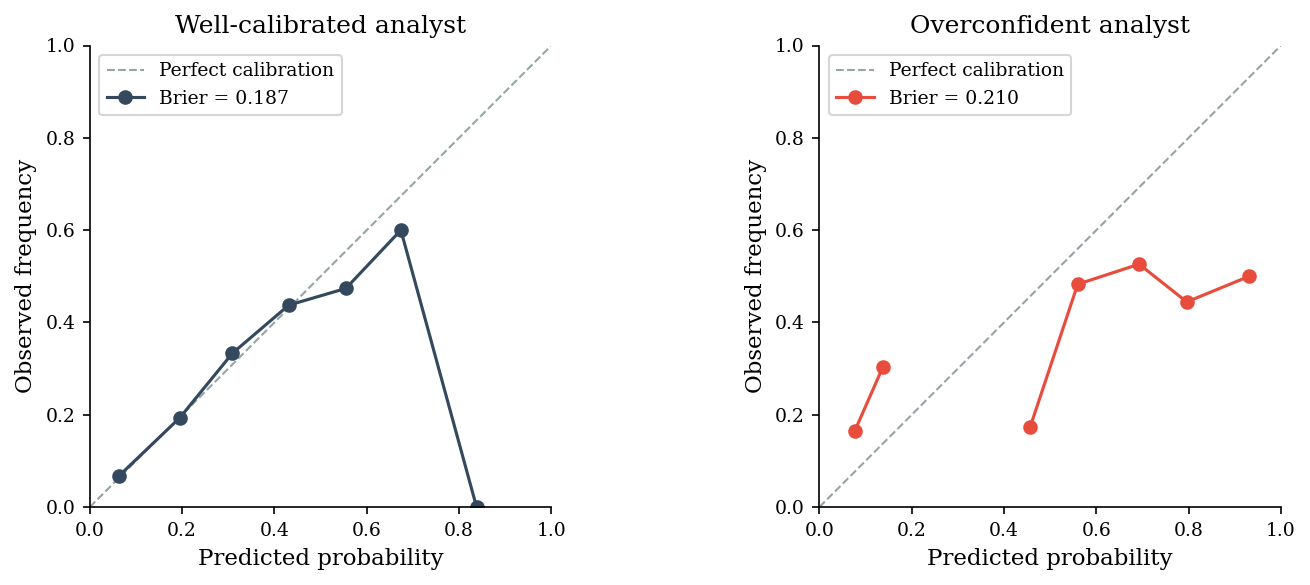

Well-calibrated Brier score: 0.187
Overconfident Brier score:   0.210
Lower Brier score = better calibration (0 is perfect).


In [8]:
n_preds = 200
true_probs = rng.beta(2, 5, n_preds)  # ground truth: skewed toward low probs
outcomes = rng.binomial(1, true_probs)

# Well-calibrated analyst: adds small noise to true probabilities
calibrated_forecasts = true_probs + rng.normal(0, 0.05, n_preds)
calibrated_forecasts = np.clip(calibrated_forecasts, 0.01, 0.99)

# Overconfident analyst: pushes predictions away from the base rate
overconfident_forecasts = np.where(
    true_probs > 0.3,
    np.clip(true_probs * 1.4, 0, 0.99),
    np.clip(true_probs * 0.5, 0.01, 1)
)

bs_cal = brier_score(calibrated_forecasts, outcomes)
bs_over = brier_score(overconfident_forecasts, outcomes)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, forecasts, label, bs, color in [
    (axes[0], calibrated_forecasts, "Well-calibrated analyst", bs_cal, DARK_BG),
    (axes[1], overconfident_forecasts, "Overconfident analyst", bs_over, ACCENT),
]:
    bins_c, observed = calibration_curve(forecasts, outcomes, bins=8)
    ax.plot([0, 1], [0, 1], "--", color=LIGHT_GRAY, linewidth=1,
            label="Perfect calibration")
    ax.plot(bins_c, observed, "o-", color=color, markersize=6,
            label=f"Brier = {bs:.3f}")
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title(label)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect("equal")
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

print(f"Well-calibrated Brier score: {bs_cal:.3f}")
print(f"Overconfident Brier score:   {bs_over:.3f}")
print("Lower Brier score = better calibration (0 is perfect).")

The well-calibrated analyst's dots hug the diagonal: when they say 30%, it happens
about 30% of the time. The overconfident analyst's curve deviates systematically,
and the higher Brier score reflects this.

**Why this matters for Bayesian updating:** if your prior probabilities are
miscalibrated, every subsequent update inherits that bias. Garbage in, garbage out
--- even with perfect likelihood ratios. Calibration training (predict, observe,
score, adjust) is the single highest-leverage improvement for any threat intel team.

## 6. Pitfalls and Practical Guidance

**Base rate neglect is the #1 Bayesian failure in security.** A 95%-accurate threat
detector applied to a 0.1% base rate produces 98% false positives. Always start with
the prior.

**Likelihood ratios, not hit rates, determine evidence strength.** An indicator with
95% TPR but 8% FPR (antivirus) is weaker evidence than one with 85% TPR and 0.1% FPR
(C2 domain). The ratio matters, not the absolute numbers.

**Sequential updating requires source independence.** If two threat intel feeds share
the same upstream source, double-updating inflates confidence. Know your intelligence
supply chain.

**Overconfidence compounds.** If every estimate in your chain is 20% too confident,
the final posterior can be wildly wrong. Calibrate your inputs before trusting your
outputs. Section 5 showed how to measure this --- make it a regular practice.

**The base rate is not optional.** "But we don't know the base rate" is not an excuse
to skip it. An uncertain prior (wide Beta) is still better than an implicit prior of
50%, which is what you get when you ignore base rates entirely.

---

> **Next:** Part 1.3 covers experiment design for security --- how to structure A/B
> tests and observational studies when you can't randomize who gets attacked.